In [20]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

import torch
from torch. utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

In [21]:
train_data_path = r'..\data\Training'
test_data_path = r'..\data\Testing'


train_data_path

'..\\data\\Training'

In [22]:
def walk_through(data_path):
    for (root, dirs, filenames) in os.walk(data_path):
        if root == data_path:
            continue
        class_image = os.path.relpath(root, data_path)    
        print(f"Le nombre d'images dans la classe {class_image} est : {len(filenames)}")
        
walk_through(train_data_path)

Le nombre d'images dans la classe glioma est : 1400
Le nombre d'images dans la classe meningioma est : 1400
Le nombre d'images dans la classe notumor est : 1400
Le nombre d'images dans la classe pituitary est : 1400


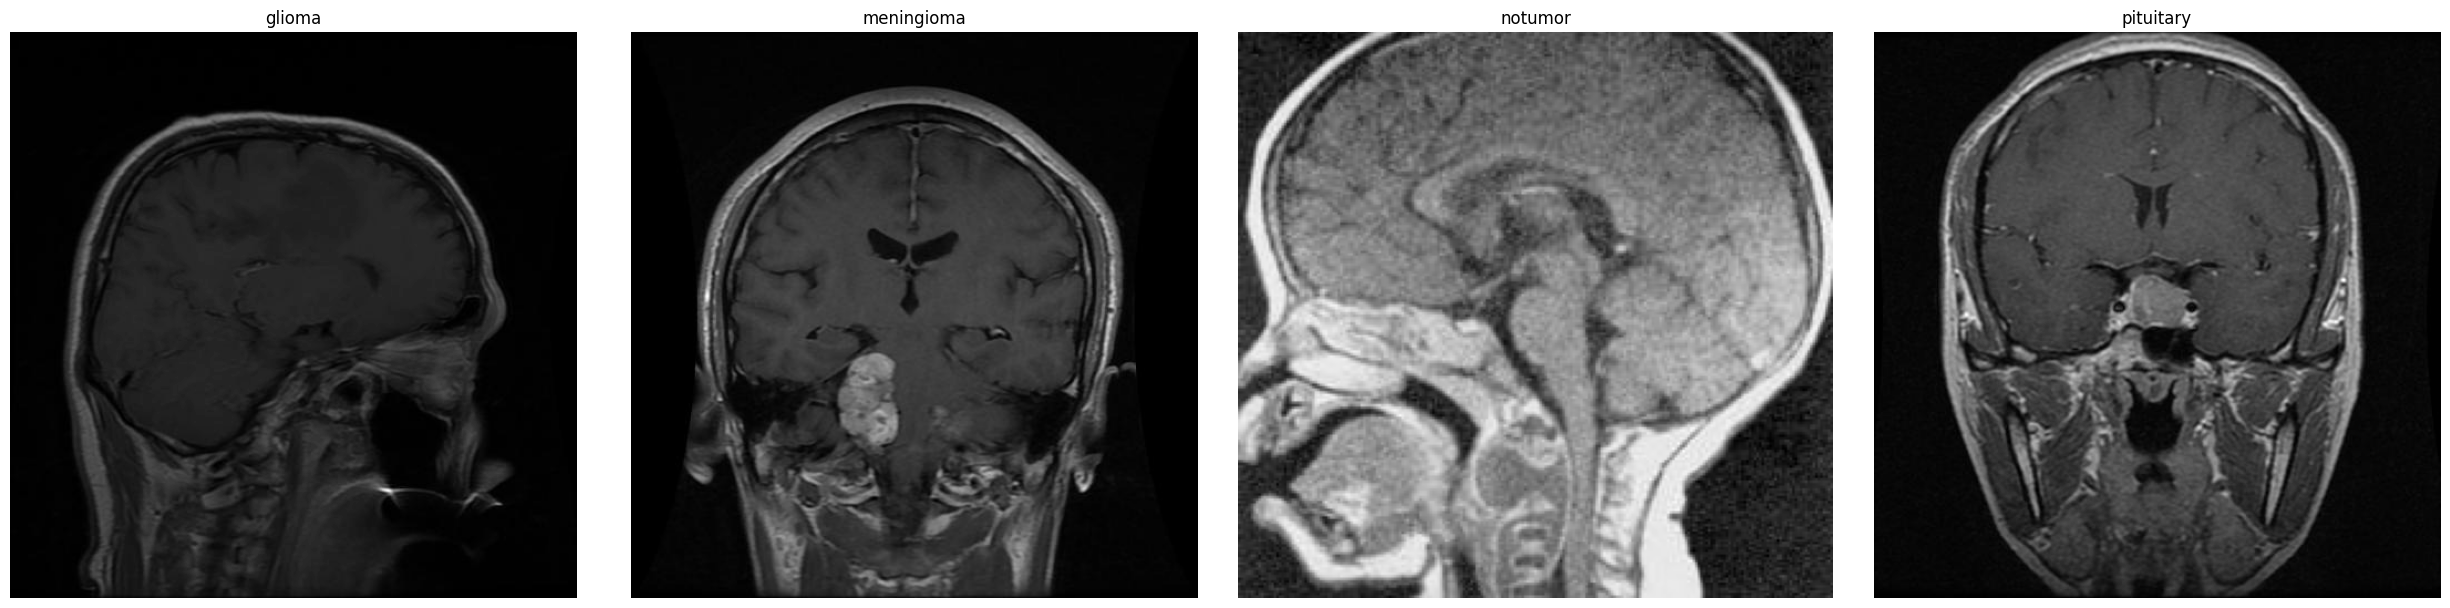

In [23]:
data_path = r'..\data\Training'
# Liste des classes
classes = [folder for folder in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, folder))]

# Taille de la grille
n_classes = len(classes)
cols = 4
rows = (n_classes // cols) + 1

plt.figure(figsize=(25, rows * 6))

for idx, classe in enumerate(classes):
    folder_path = os.path.join(data_path, classe)
    images = os.listdir(folder_path)
    random_img = random.choice(images)

    img_path = os.path.join(folder_path, random_img)
    img = Image.open(img_path)

    plt.subplot(rows, cols, idx + 1)
    plt.imshow(img, cmap= 'gray')
    plt.title(classe, fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Code pour le redimensionnement en 64 * 64 et normalisation entre -1 et 1

train_transforms = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std= [0.5, 0.5, 0.5])
])

test_transforms = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std= [0.5, 0.5, 0.5])
])

In [25]:
train_dataset = ImageFolder(
    train_data_path,
    transform= train_transforms
)

test_dataset = ImageFolder(
    test_data_path,
    transform= test_transforms
)

In [26]:
# Création du Data Loader 

train_data_loader = DataLoader(
    dataset= train_dataset,
    shuffle= True,
    batch_size= 32
)

test_data_loader = DataLoader(
    dataset= test_dataset,
    batch_size= 32
)

In [31]:
img, label = next(iter(train_data_loader))
print(img[0].shape)
print(label[0])

torch.Size([3, 64, 64])
tensor(1)


In [32]:
train_dataset.class_to_idx

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}